# Quantum Mechanics Toolkit — Pedagogical Tutorial

This notebook is a complete, hands-on guide to `qm.py`, a Python module that
provides the most commonly used matrices and state vectors in quantum mechanics.
Every object is available in **two forms**:

| Suffix | Backend | Use |
|--------|---------|-----|
| (none) | **NumPy** `complex128` | Fast numerical computation |
| `_sym` | **SymPy** `Matrix` | Exact symbolic manipulation |

Units: $\hbar = 1$ throughout (natural units for spin).

## Sections

1. [Spin-½ Matrices](#2.-Spin-½-Matrices)
2. [Spin-½ Eigenstates](#3.-Spin-½-Eigenstates)
3. [Spin-½ Ladder Operators](#4.-Spin-½-Ladder-Operators)
4. [Spin-1 Matrices](#5.-Spin-1-Matrices)
5. [Spin-1 Eigenstates](#6.-Spin-1-Eigenstates)
6. [Photon Polarization](#7.-Photon-Polarization)
7. [Helper Functions Summary](#8.-Helper-Functions-Summary)
8. [Mini Problems](#9.-Mini-Problems)

**Audience:** Upper-division undergraduate physics — assumes bra-ket notation
and familiarity with linear algebra.

In [64]:
import numpy as np
import sympy as sp
from IPython.display import display, Math
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-darkgrid')

# qm.py must reside in the same directory as this notebook
from qm import *

print("✓  qm module loaded")
print(f"   NumPy  {np.__version__}")
print(f"   SymPy  {sp.__version__}")

✓  qm module loaded
   NumPy  2.3.1
   SymPy  1.13.3


---
## 2. Spin-½ Matrices — The Pauli Matrices

The **Pauli matrices** $\sigma_x,\,\sigma_y,\,\sigma_z$ are the generators of
SU(2) rotations for a spin-$\tfrac{1}{2}$ particle.
In the standard $z$-basis $\{|\!\uparrow\rangle,\,|\!\downarrow\rangle\}$ they satisfy:

$$
\sigma_i^2 = I, \qquad
[\sigma_i,\,\sigma_j] = 2i\,\varepsilon_{ijk}\,\sigma_k, \qquad
\{\sigma_i,\,\sigma_j\} = 2\delta_{ij}\,I
$$

The factor of 2 in the commutator (vs. the general angular-momentum relation
$[J_i,J_j]=i\varepsilon_{ijk}J_k$) arises because $\sigma_i = 2J_i$ for spin-½.

In [65]:
# NumPy Pauli matrices
print("── NumPy Pauli Matrices ──\n")
for lbl, mat in [('sigma_x', sigma_x), ('sigma_y', sigma_y), ('sigma_z', sigma_z)]:
    print(f"{lbl} =\n{mat}\n")

── NumPy Pauli Matrices ──

sigma_x =
[[0.+0.j 1.+0.j]
 [1.+0.j 0.+0.j]]

sigma_y =
[[ 0.+0.j -0.-1.j]
 [ 0.+1.j  0.+0.j]]

sigma_z =
[[ 1.+0.j  0.+0.j]
 [ 0.+0.j -1.+0.j]]



In [66]:
# SymPy Pauli matrices — rendered as LaTeX
print("── SymPy Pauli Matrices (exact) ──\n")
for lbl, mat in [(r'\sigma_x', sigma_x_sym),
                 (r'\sigma_y', sigma_y_sym),
                 (r'\sigma_z', sigma_z_sym)]:
    display(Math(lbl + r' = ' + sp.latex(mat)))

── SymPy Pauli Matrices (exact) ──



<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [67]:
# Verify  σᵢ² = I  (NumPy and SymPy)
print("── Verification: σᵢ² = I ──\n")

print("NumPy:")
for lbl, mat in [('sigma_x', sigma_x), ('sigma_y', sigma_y), ('sigma_z', sigma_z)]:
    ok = np.allclose(mat @ mat, I2)
    print(f"  {lbl}² = I ?  {ok}")

print("\nSymPy:")
for lbl, mat in [(r'\sigma_x', sigma_x_sym),
                 (r'\sigma_y', sigma_y_sym),
                 (r'\sigma_z', sigma_z_sym)]:
    result = sp.simplify(mat * mat)
    display(Math(lbl + r'^2 = ' + sp.latex(result)))

── Verification: σᵢ² = I ──

NumPy:
  sigma_x² = I ?  True
  sigma_y² = I ?  True
  sigma_z² = I ?  True

SymPy:


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [68]:
# Verify commutation relations  [σᵢ, σⱼ] = 2i εᵢⱼₖ σₖ
print("── Commutation Relations  [σᵢ, σⱼ] = 2i εᵢⱼₖ σₖ ──\n")

cyclic = [
    (sigma_x, sigma_y, sigma_z, 'x', 'y', 'z'),
    (sigma_y, sigma_z, sigma_x, 'y', 'z', 'x'),
    (sigma_z, sigma_x, sigma_y, 'z', 'x', 'y'),
]

print("NumPy:")
for A, B, C, i, j, k in cyclic:
    ok = np.allclose(comm(A, B), 2j * C)
    print(f"  [σ_{i}, σ_{j}] = 2i·σ_{k} ?  {ok}")

print("\nSymPy:")
cyclic_sym = [
    (sigma_x_sym, sigma_y_sym, r'\sigma_x', r'\sigma_y'),
    (sigma_y_sym, sigma_z_sym, r'\sigma_y', r'\sigma_z'),
    (sigma_z_sym, sigma_x_sym, r'\sigma_z', r'\sigma_x'),
]
for A, B, la, lb in cyclic_sym:
    res = comm(A, B)
    display(Math(r'[\,' + la + r',\,' + lb + r'\,] = ' + sp.latex(res)))

── Commutation Relations  [σᵢ, σⱼ] = 2i εᵢⱼₖ σₖ ──

NumPy:
  [σ_x, σ_y] = 2i·σ_z ?  True
  [σ_y, σ_z] = 2i·σ_x ?  True
  [σ_z, σ_x] = 2i·σ_y ?  True

SymPy:


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

/var/folders/kn/tzxn1n013x11jb707_7_4c7m0000gq/T/ipykernel_64712/3876773393.py:25: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


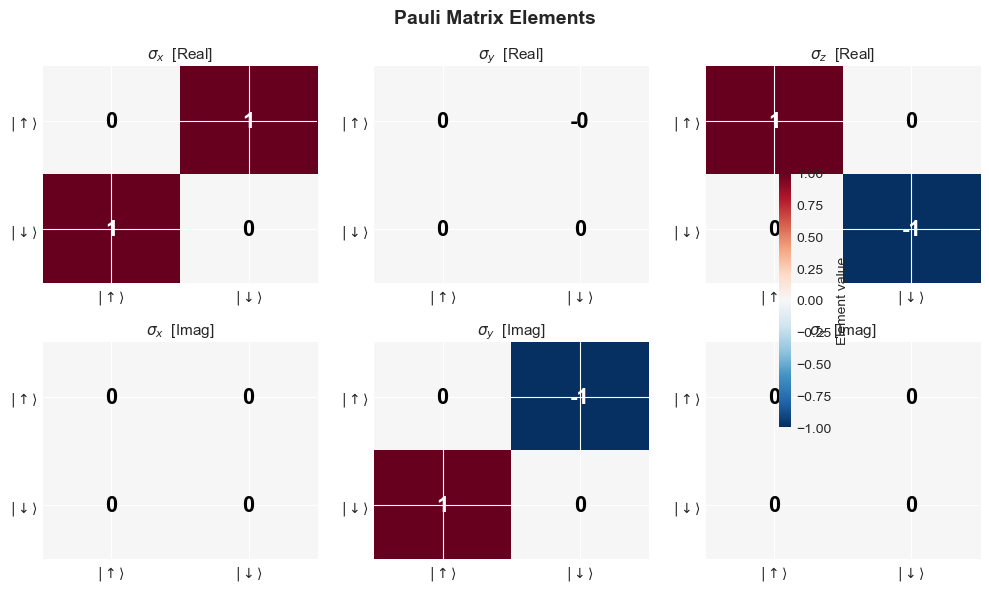

In [69]:
# Heatmaps — real and imaginary parts of each Pauli matrix
fig, axes = plt.subplots(2, 3, figsize=(10, 6))
fig.suptitle('Pauli Matrix Elements', fontsize=14, fontweight='bold')

mats_h = [sigma_x,         sigma_y,         sigma_z        ]
lbls_h = [r'$\sigma_x$',   r'$\sigma_y$',   r'$\sigma_z$'  ]
ticks  = [r'$|\uparrow\rangle$', r'$|\downarrow\rangle$']

for col, (mat, lbl) in enumerate(zip(mats_h, lbls_h)):
    for row, (fn, plbl) in enumerate([(np.real, 'Real'), (np.imag, 'Imag')]):
        ax   = axes[row, col]
        data = fn(mat)
        im   = ax.imshow(data, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
        ax.set_title(f'{lbl}  [{plbl}]', fontsize=11)
        ax.set_xticks([0, 1]); ax.set_xticklabels(ticks)
        ax.set_yticks([0, 1]); ax.set_yticklabels(ticks)
        for i in range(2):
            for j in range(2):
                v = data[i, j]
                ax.text(j, i, f'{v:.0f}', ha='center', va='center',
                        fontsize=16, fontweight='bold',
                        color='white' if abs(v) > 0.5 else 'black')

fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.55, label='Element value')
plt.tight_layout()
plt.show()

---
## 3. Spin-½ Eigenstates

Six standard eigenstates — two per Pauli operator:

| State | Eigenvalue | Column vector |
|-------|-----------|---------------|
| $\lvert+\rangle$ | $\sigma_z = +1$ | $[1,\;0]^\top$ |
| $\lvert-\rangle$ | $\sigma_z = -1$ | $[0,\;1]^\top$ |
| $\lvert+x\rangle$ | $\sigma_x = +1$ | $\tfrac{1}{\sqrt{2}}[1,\;+1]^\top$ |
| $\lvert-x\rangle$ | $\sigma_x = -1$ | $\tfrac{1}{\sqrt{2}}[1,\;-1]^\top$ |
| $\lvert+y\rangle$ | $\sigma_y = +1$ | $\tfrac{1}{\sqrt{2}}[1,\;+i]^\top$ |
| $\lvert-y\rangle$ | $\sigma_y = -1$ | $\tfrac{1}{\sqrt{2}}[1,\;-i]^\top$ |

Each pair is **orthonormal** and forms a **complete** basis for $\mathbb{C}^2$.

In [70]:
# Display all six eigenstates — NumPy
print("── Spin-½ Eigenstates (NumPy) ──\n")
state_np = [spin_up, spin_down, xplus, xminus, yplus, yminus]
name_np  = ['spin_up  |+⟩', 'spin_down |−⟩',
            'xplus  |+x⟩',  'xminus |−x⟩',
            'yplus  |+y⟩',  'yminus |−y⟩']
for name, psi in zip(name_np, state_np):
    print(f"  {name}: {psi.T}")

── Spin-½ Eigenstates (NumPy) ──

  spin_up  |+⟩: [[1.+0.j 0.+0.j]]
  spin_down |−⟩: [[0.+0.j 1.+0.j]]
  xplus  |+x⟩: [[0.70710678+0.j 0.70710678+0.j]]
  xminus |−x⟩: [[ 0.70710678+0.j -0.70710678+0.j]]
  yplus  |+y⟩: [[0.70710678+0.j         0.        +0.70710678j]]
  yminus |−y⟩: [[0.70710678+0.j         0.        -0.70710678j]]


In [71]:
# Display all six eigenstates — SymPy
print("── Spin-½ Eigenstates (SymPy) ──\n")
state_sym = [spin_up_sym, spin_down_sym,
             xplus_sym,   xminus_sym,
             yplus_sym,   yminus_sym]
name_sym  = [r'\lvert+\rangle',  r'\lvert-\rangle',
             r'\lvert+x\rangle', r'\lvert-x\rangle',
             r'\lvert+y\rangle', r'\lvert-y\rangle']
for name, psi in zip(name_sym, state_sym):
    display(Math(name + r' = ' + sp.latex(psi)))

── Spin-½ Eigenstates (SymPy) ──



<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [72]:
# Verify eigenvalue equations — NumPy
print("── Eigenvalue Equations (NumPy) ──\n")
ev_tests = [
    (sigma_z, spin_up,   +1, 'σ_z', '|+⟩'),
    (sigma_z, spin_down, -1, 'σ_z', '|−⟩'),
    (sigma_x, xplus,     +1, 'σ_x', '|+x⟩'),
    (sigma_x, xminus,    -1, 'σ_x', '|−x⟩'),
    (sigma_y, yplus,     +1, 'σ_y', '|+y⟩'),
    (sigma_y, yminus,    -1, 'σ_y', '|−y⟩'),
]
for A, psi, ev, Albl, plbl in ev_tests:
    ok = np.allclose(A @ psi, ev * psi)
    print(f"  {Albl} {plbl} = {ev:+d}·{plbl} ?  {ok}")

── Eigenvalue Equations (NumPy) ──

  σ_z |+⟩ = +1·|+⟩ ?  True
  σ_z |−⟩ = -1·|−⟩ ?  True
  σ_x |+x⟩ = +1·|+x⟩ ?  True
  σ_x |−x⟩ = -1·|−x⟩ ?  True
  σ_y |+y⟩ = +1·|+y⟩ ?  True
  σ_y |−y⟩ = -1·|−y⟩ ?  True


In [120]:
# Verify eigenvalue equations — SymPy
print("── Eigenvalue Equations (SymPy) ──\n")
ev_sym = [
    (sigma_z_sym, spin_up_sym,   +1, r'\sigma_z', r'\lvert+\rangle'),
    (sigma_z_sym, spin_down_sym, -1, r'\sigma_z', r'\lvert-\rangle'),
    (sigma_x_sym, xplus_sym,     +1, r'\sigma_x', r'\lvert+x\rangle'),
    (sigma_x_sym, xminus_sym,    -1, r'\sigma_x', r'\lvert-x\rangle'),
]
for A, psi, ev, Albl, plbl in ev_sym:
    lhs = sp.simplify(A * psi)
    display(Math(Albl + r'\,' + plbl + r' = ' + sp.latex(lhs)))

── Eigenvalue Equations (SymPy) ──



<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [74]:
# Verify orthonormality using dagger()
print("── Orthonormality (using dagger) ──\n")

bases = [
    ('σ_z', [(spin_up, '|+⟩'), (spin_down, '|−⟩')]),
    ('σ_x', [(xplus,  '|+x⟩'), (xminus,   '|−x⟩')]),
    ('σ_y', [(yplus,  '|+y⟩'), (yminus,   '|−y⟩')]),
]
for basis_name, pairs in bases:
    print(f"{basis_name} basis:")
    for si, li in pairs:
        for sj, lj in pairs:
            v = (dagger(si) @ sj)[0, 0]
            print(f"  ⟨{li[1:-1]}|{lj[1:-1]}⟩ = {v.real:+.4f}{v.imag:+.4f}j")
    print()

── Orthonormality (using dagger) ──

σ_z basis:
  ⟨+|+⟩ = +1.0000+0.0000j
  ⟨+|−⟩ = +0.0000+0.0000j
  ⟨−|+⟩ = +0.0000+0.0000j
  ⟨−|−⟩ = +1.0000+0.0000j

σ_x basis:
  ⟨+x|+x⟩ = +1.0000+0.0000j
  ⟨+x|−x⟩ = +0.0000+0.0000j
  ⟨−x|+x⟩ = +0.0000+0.0000j
  ⟨−x|−x⟩ = +1.0000+0.0000j

σ_y basis:
  ⟨+y|+y⟩ = +1.0000+0.0000j
  ⟨+y|−y⟩ = +0.0000+0.0000j
  ⟨−y|+y⟩ = +0.0000+0.0000j
  ⟨−y|−y⟩ = +1.0000+0.0000j



In [75]:
# Completeness  Σ_i |i⟩⟨i| = I  for each basis
print("── Completeness Relations ──\n")
comp_z = spin_up @ dagger(spin_up) + spin_down @ dagger(spin_down)
comp_x = xplus   @ dagger(xplus)   + xminus   @ dagger(xminus)
comp_y = yplus   @ dagger(yplus)   + yminus   @ dagger(yminus)

print(f"  |+⟩⟨+| + |−⟩⟨−|     = I₂ ?  {np.allclose(comp_z, I2)}")
print(f"  |+x⟩⟨+x| + |−x⟩⟨−x| = I₂ ?  {np.allclose(comp_x, I2)}")
print(f"  |+y⟩⟨+y| + |−y⟩⟨−y| = I₂ ?  {np.allclose(comp_y, I2)}")

# SymPy — σ_z completeness
comp_z_sym = (spin_up_sym * dagger(spin_up_sym)
              + spin_down_sym * dagger(spin_down_sym))
display(Math(r'\lvert+\rangle\langle+\rvert + \lvert-\rangle\langle-\rvert = '
             + sp.latex(sp.simplify(comp_z_sym))))

── Completeness Relations ──

  |+⟩⟨+| + |−⟩⟨−|     = I₂ ?  True
  |+x⟩⟨+x| + |−x⟩⟨−x| = I₂ ?  True
  |+y⟩⟨+y| + |−y⟩⟨−y| = I₂ ?  True


<IPython.core.display.Math object>

In [76]:
# norm() and expect() on all six eigenstates
print("── norm() — all should equal 1.0 ──\n")
for name, psi in zip(name_np, state_np):
    short = name.split()[0]
    print(f"  norm({short:<10}) = {norm(psi):.10f}")

print("\n── expect(σ_z) for each eigenstate ──\n")
for name, psi in zip(name_np, state_np):
    v = expect(sigma_z, psi).real
    print(f"  ⟨σ_z⟩  {name.split()[0]:<10} = {v:+.4f}")

print("\n── expect(σ_x) for each eigenstate ──\n")
for name, psi in zip(name_np, state_np):
    v = expect(sigma_x, psi).real
    print(f"  ⟨σ_x⟩  {name.split()[0]:<10} = {v:+.4f}")

── norm() — all should equal 1.0 ──

  norm(spin_up   ) = 1.0000000000
  norm(spin_down ) = 1.0000000000
  norm(xplus     ) = 1.0000000000
  norm(xminus    ) = 1.0000000000
  norm(yplus     ) = 1.0000000000
  norm(yminus    ) = 1.0000000000

── expect(σ_z) for each eigenstate ──

  ⟨σ_z⟩  spin_up    = +1.0000
  ⟨σ_z⟩  spin_down  = -1.0000
  ⟨σ_z⟩  xplus      = +0.0000
  ⟨σ_z⟩  xminus     = +0.0000
  ⟨σ_z⟩  yplus      = +0.0000
  ⟨σ_z⟩  yminus     = +0.0000

── expect(σ_x) for each eigenstate ──

  ⟨σ_x⟩  spin_up    = +0.0000
  ⟨σ_x⟩  spin_down  = +0.0000
  ⟨σ_x⟩  xplus      = +1.0000
  ⟨σ_x⟩  xminus     = -1.0000
  ⟨σ_x⟩  yplus      = +0.0000
  ⟨σ_x⟩  yminus     = +0.0000


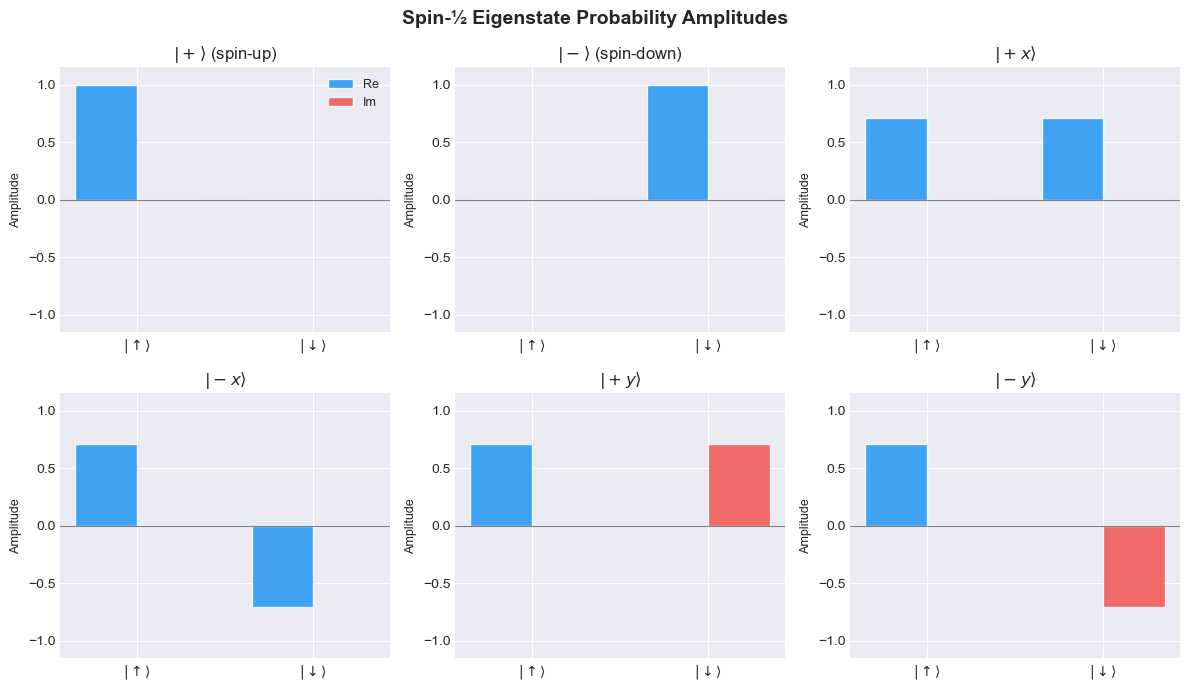

In [77]:
# Bar charts of probability amplitudes for all six eigenstates
fig, axes = plt.subplots(2, 3, figsize=(12, 7))
fig.suptitle('Spin-½ Eigenstate Probability Amplitudes', fontsize=14, fontweight='bold')

titles = [r'$|+\rangle$ (spin-up)',    r'$|-\rangle$ (spin-down)',
          r'$|+x\rangle$',             r'$|-x\rangle$',
          r'$|+y\rangle$',             r'$|-y\rangle$']
basis_lbl = [r'$|\uparrow\rangle$', r'$|\downarrow\rangle$']
x = np.arange(2)
w = 0.35

for idx, (ax, psi, title) in enumerate(zip(axes.flat, state_np, titles)):
    re = psi.real.flatten()
    im = psi.imag.flatten()
    ax.bar(x - w/2, re, w, label='Re', color='#2196F3', alpha=0.85, edgecolor='white')
    ax.bar(x + w/2, im, w, label='Im', color='#EF5350', alpha=0.85, edgecolor='white')
    ax.set_title(title, fontsize=12)
    ax.set_xticks(x); ax.set_xticklabels(basis_lbl, fontsize=10)
    ax.set_ylim(-1.15, 1.15)
    ax.axhline(0, color='gray', lw=0.8)
    ax.set_ylabel('Amplitude', fontsize=9)
    if idx == 0:
        ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

---
## 4. Spin-½ Ladder Operators

The **raising** ($\sigma_+$) and **lowering** ($\sigma_-$) operators are:

$$
\sigma_\pm = \tfrac{1}{2}(\sigma_x \pm i\sigma_y)
$$

They act on the $z$-eigenstates as:

| Action | Result |
|--------|--------|
| $\sigma_+\lvert-\rangle$ | $\lvert+\rangle$ |
| $\sigma_-\lvert+\rangle$ | $\lvert-\rangle$ |
| $\sigma_+\lvert+\rangle$ | $0\phantom{\rangle}$ (annihilation) |
| $\sigma_-\lvert-\rangle$ | $0\phantom{\rangle}$ (annihilation) |

They also reconstruct $\sigma_x$ and $\sigma_y$:
$\sigma_x = \sigma_+ + \sigma_-$ and $\sigma_y = i(\sigma_- - \sigma_+)$.

In [78]:
# Matrix form of the ladder operators
print("── σ₊ (NumPy) ──")
print(sigma_plus)
print("\n── σ₋ (NumPy) ──")
print(sigma_minus)

── σ₊ (NumPy) ──
[[0.+0.j 1.+0.j]
 [0.+0.j 0.+0.j]]

── σ₋ (NumPy) ──
[[0.+0.j 0.+0.j]
 [1.+0.j 0.+0.j]]


In [79]:
# SymPy ladder operators
print("── Ladder Operators (SymPy) ──\n")
display(Math(r'\sigma_+ = ' + sp.latex(sigma_plus_sym)))
display(Math(r'\sigma_- = ' + sp.latex(sigma_minus_sym)))

── Ladder Operators (SymPy) ──



<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [80]:
# Raising and lowering actions — NumPy
print("── Raising / Lowering (NumPy) ──\n")
res_raise = sigma_plus  @ spin_down
res_lower = sigma_minus @ spin_up
print(f"σ₊ |−⟩ = {res_raise.T}   equals |+⟩ ? {np.allclose(res_raise, spin_up)}")
print(f"σ₋ |+⟩ = {res_lower.T}   equals |−⟩ ? {np.allclose(res_lower, spin_down)}")

── Raising / Lowering (NumPy) ──

σ₊ |−⟩ = [[1.+0.j 0.+0.j]]   equals |+⟩ ? True
σ₋ |+⟩ = [[0.+0.j 1.+0.j]]   equals |−⟩ ? True


In [81]:
# Raising / lowering — SymPy
print("── Raising / Lowering (SymPy) ──\n")
display(Math(r'\sigma_+\lvert-\rangle = '
             + sp.latex(sigma_plus_sym * spin_down_sym)))
display(Math(r'\sigma_-\lvert+\rangle = '
             + sp.latex(sigma_minus_sym * spin_up_sym)))

── Raising / Lowering (SymPy) ──



<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [82]:
# Annihilation at boundary states
print("── Annihilation at Boundaries ──\n")
top = sigma_plus  @ spin_up
bot = sigma_minus @ spin_down
print(f"σ₊ |+⟩ = {top.T}   zero ? {np.allclose(top, np.zeros((2,1)))}")
print(f"σ₋ |−⟩ = {bot.T}   zero ? {np.allclose(bot, np.zeros((2,1)))}")

── Annihilation at Boundaries ──

σ₊ |+⟩ = [[0.+0.j 0.+0.j]]   zero ? True
σ₋ |−⟩ = [[0.+0.j 0.+0.j]]   zero ? True


In [83]:
# Reconstruction of σ_x and σ_y from σ±, and commutator algebra
print("── Reconstruction of σ_x, σ_y from σ± ──\n")
sx_rec = sigma_plus + sigma_minus
sy_rec = 1j * (sigma_minus - sigma_plus)
print(f"σ₊ + σ₋        = σ_x ?  {np.allclose(sx_rec, sigma_x)}")
print(f"i(σ₋ − σ₊)     = σ_y ?  {np.allclose(sy_rec, sigma_y)}")
print(f"[σ₊, σ₋]       = σ_z ?  {np.allclose(comm(sigma_plus, sigma_minus), sigma_z)}")

print("\nSymPy reconstruction:")
sx_sym_rec = sp.simplify(sigma_plus_sym + sigma_minus_sym)
sy_sym_rec = sp.simplify(sp.I * (sigma_minus_sym - sigma_plus_sym))
display(Math(r'\sigma_+ + \sigma_- = ' + sp.latex(sx_sym_rec)))
display(Math(r'i(\sigma_- - \sigma_+) = ' + sp.latex(sy_sym_rec)))

── Reconstruction of σ_x, σ_y from σ± ──

σ₊ + σ₋        = σ_x ?  True
i(σ₋ − σ₊)     = σ_y ?  True
[σ₊, σ₋]       = σ_z ?  True

SymPy reconstruction:


<IPython.core.display.Math object>

<IPython.core.display.Math object>

---
## 5. Spin-1 Matrices

For a **spin-1** particle the angular-momentum operators $J_x, J_y, J_z$ are
$3\times3$ matrices ($\hbar = 1$) in the ordered basis
$\{\lvert m{=}+1\rangle,\,\lvert m{=}0\rangle,\,\lvert m{=}-1\rangle\}$.

They satisfy the same SU(2) algebra, but the Casimir operator gives:

$$
[J_i,\,J_j] = i\,\varepsilon_{ijk}\,J_k, \qquad
\mathbf{J}^2 = j(j+1)\,I = 2I \quad (j = 1)
$$

Matrix elements follow from
$\langle m'|J_\pm|m\rangle = \sqrt{j(j+1)-m(m\pm 1)}$.

In [84]:
# Spin-1 matrices — NumPy
print("── Spin-1 Matrices (NumPy) ──\n")
for lbl, mat in [('jx', jx), ('jy', jy), ('jz', jz)]:
    print(f"{lbl} =\n{np.round(mat, 6)}\n")

── Spin-1 Matrices (NumPy) ──

jx =
[[0.      +0.j 0.707107+0.j 0.      +0.j]
 [0.707107+0.j 0.      +0.j 0.707107+0.j]
 [0.      +0.j 0.707107+0.j 0.      +0.j]]

jy =
[[0.+0.j       0.-0.707107j 0.+0.j      ]
 [0.+0.707107j 0.+0.j       0.-0.707107j]
 [0.+0.j       0.+0.707107j 0.+0.j      ]]

jz =
[[ 1.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j -1.+0.j]]



In [85]:
# Spin-1 matrices — SymPy
print("── Spin-1 Matrices (SymPy) ──\n")
for lbl, mat in [(r'J_x', jx_sym), (r'J_y', jy_sym), (r'J_z', jz_sym)]:
    display(Math(lbl + r' = ' + sp.latex(mat)))

── Spin-1 Matrices (SymPy) ──



<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [86]:
# Verify commutation relations  [Jᵢ, Jⱼ] = i Jₖ
print("── Commutation Relations  [Jᵢ, Jⱼ] = i Jₖ ──\n")
cyc1 = [
    (jx, jy, jz, 'x', 'y', 'z'),
    (jy, jz, jx, 'y', 'z', 'x'),
    (jz, jx, jy, 'z', 'x', 'y'),
]
print("NumPy:")
for A, B, C, i, j, k in cyc1:
    ok = np.allclose(comm(A, B), 1j * C)
    print(f"  [J_{i}, J_{j}] = i·J_{k} ?  {ok}")

print("\nSymPy:")
for A, B, la, lb in [(jx_sym, jy_sym, r'J_x', r'J_y'),
                     (jy_sym, jz_sym, r'J_y', r'J_z'),
                     (jz_sym, jx_sym, r'J_z', r'J_x')]:
    display(Math(r'[\,' + la + r',\,' + lb + r'\,] = ' + sp.latex(comm(A, B))))

── Commutation Relations  [Jᵢ, Jⱼ] = i Jₖ ──

NumPy:
  [J_x, J_y] = i·J_z ?  True
  [J_y, J_z] = i·J_x ?  True
  [J_z, J_x] = i·J_y ?  True

SymPy:


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [87]:
# Verify  J² = j(j+1) I = 2I  for j=1
print("── Casimir Operator J² = 2·I₃ ──\n")
j2_np = jx @ jx + jy @ jy + jz @ jz
print(f"NumPy:  J² = 2·I₃ ?  {np.allclose(j2_np, 2 * I3)}")
print(f"\nJ² =\n{np.round(j2_np.real, 8)}")

j2_sym = sp.simplify(jx_sym**2 + jy_sym**2 + jz_sym**2)
display(Math(r'\mathbf{J}^2 = J_x^2 + J_y^2 + J_z^2 = ' + sp.latex(j2_sym)))

── Casimir Operator J² = 2·I₃ ──

NumPy:  J² = 2·I₃ ?  True

J² =
[[2. 0. 0.]
 [0. 2. 0.]
 [0. 0. 2.]]


<IPython.core.display.Math object>

/var/folders/kn/tzxn1n013x11jb707_7_4c7m0000gq/T/ipykernel_64712/1447577939.py:27: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


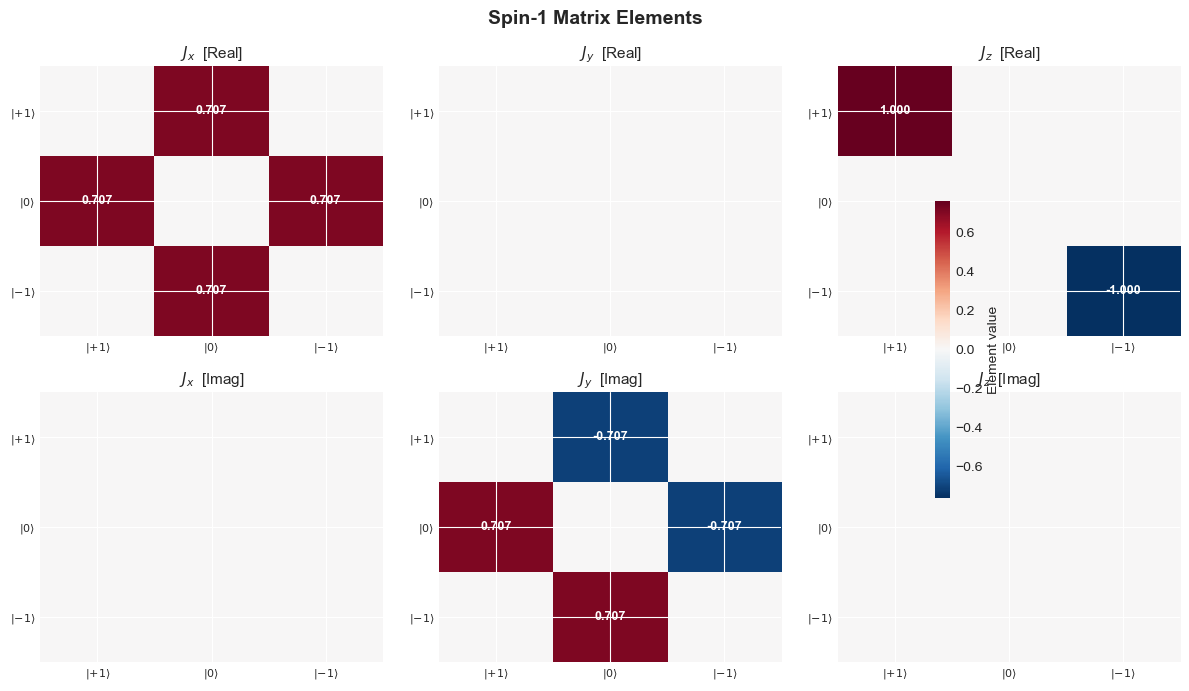

In [88]:
# Heatmaps — real and imaginary parts of each spin-1 matrix
fig, axes = plt.subplots(2, 3, figsize=(12, 7))
fig.suptitle('Spin-1 Matrix Elements', fontsize=14, fontweight='bold')

mats_j = [jx,         jy,         jz        ]
lbls_j = [r'$J_x$',   r'$J_y$',   r'$J_z$'  ]
tkj    = [r'$|{+1}\rangle$', r'$|0\rangle$', r'$|{-1}\rangle$']
vmax   = 1 / np.sqrt(2) + 0.05

for col, (mat, lbl) in enumerate(zip(mats_j, lbls_j)):
    for row, (fn, plbl) in enumerate([(np.real, 'Real'), (np.imag, 'Imag')]):
        ax   = axes[row, col]
        data = fn(mat)
        im   = ax.imshow(data, cmap='RdBu_r', vmin=-vmax, vmax=vmax, aspect='auto')
        ax.set_title(f'{lbl}  [{plbl}]', fontsize=11)
        ax.set_xticks([0,1,2]); ax.set_xticklabels(tkj, fontsize=8)
        ax.set_yticks([0,1,2]); ax.set_yticklabels(tkj, fontsize=8)
        for i in range(3):
            for j in range(3):
                v = data[i, j]
                if abs(v) > 0.02:
                    ax.text(j, i, f'{v:.3f}', ha='center', va='center',
                            fontsize=9, fontweight='bold',
                            color='white' if abs(v) > 0.55 else 'black')

fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.55, label='Element value')
plt.tight_layout()
plt.show()

---
## 6. Spin-1 Eigenstates

The three $J_z$ eigenstates for $j=1$:

$$
J_z\,|m\rangle = m\,|m\rangle, \quad m \in \{+1,\, 0,\, -1\}
$$

Ladder operators carry a **$\sqrt{2}$ factor** from the Clebsch–Gordan formula:

$$
J_\pm\,|m\rangle = \sqrt{2 - m(m\pm 1)}\,|m\pm 1\rangle
$$

giving, for example, $J_+|0\rangle = \sqrt{2}\,|{+1}\rangle$ and
$J_-|0\rangle = \sqrt{2}\,|{-1}\rangle$.

In [89]:
# Display spin-1 eigenstates — NumPy
print("── Spin-1 Eigenstates (NumPy) ──\n")
for name, psi in [('jm1   |m=+1⟩', jm1),
                  ('j0    |m= 0⟩',  j0),
                  ('jm_1  |m=−1⟩',  jm_1)]:
    print(f"  {name}: {psi.T}")

── Spin-1 Eigenstates (NumPy) ──

  jm1   |m=+1⟩: [[1.+0.j 0.+0.j 0.+0.j]]
  j0    |m= 0⟩: [[0.+0.j 1.+0.j 0.+0.j]]
  jm_1  |m=−1⟩: [[0.+0.j 0.+0.j 1.+0.j]]


In [90]:
# Display spin-1 eigenstates — SymPy
print("── Spin-1 Eigenstates (SymPy) ──\n")
for lbl, psi in [(r'\lvert m{=}+1\rangle', jm1_sym),
                 (r'\lvert m{=}0\rangle',   j0_sym),
                 (r'\lvert m{=}-1\rangle',  jm_1_sym)]:
    display(Math(lbl + r' = ' + sp.latex(psi)))

── Spin-1 Eigenstates (SymPy) ──



<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [91]:
# Verify J_z eigenvalues — NumPy and SymPy
print("── J_z Eigenvalue Verification ──\n")
print("NumPy:")
for ev, psi, name in [(+1, jm1, '|m=+1⟩'), (0, j0, '|m=0⟩'), (-1, jm_1, '|m=−1⟩')]:
    ok = np.allclose(jz @ psi, ev * psi)
    print(f"  J_z {name} = {ev:+d}·{name} ?  {ok}")

print("\nSymPy:")
for ev, psi, lbl in [(1,  jm1_sym,  r'm{=}+1'),
                     (0,  j0_sym,   r'm{=}0'),
                     (-1, jm_1_sym, r'm{=}-1')]:
    res = sp.simplify(jz_sym * psi)
    display(Math(r'J_z\lvert' + lbl + r'\rangle = ' + sp.latex(res)))

── J_z Eigenvalue Verification ──

NumPy:
  J_z |m=+1⟩ = +1·|m=+1⟩ ?  True
  J_z |m=0⟩ = +0·|m=0⟩ ?  True
  J_z |m=−1⟩ = -1·|m=−1⟩ ?  True

SymPy:


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [92]:
# Demonstrate ladder actions with √2 factors
print("── Ladder Operator Actions ──\n")
rt2 = np.sqrt(2)

print("J₊ actions:")
print(f"  J₊ |m= 0⟩ = √2·|m=+1⟩ ?  {np.allclose(jplus @ j0,   rt2 * jm1)}")
print(f"  J₊ |m=−1⟩ = √2·|m= 0⟩ ?  {np.allclose(jplus @ jm_1, rt2 * j0)}")
print(f"  J₊ |m=+1⟩ =  0         ?  {np.allclose(jplus @ jm1,  np.zeros((3,1)))}")

print("\nJ₋ actions:")
print(f"  J₋ |m=+1⟩ = √2·|m= 0⟩ ?  {np.allclose(jminus @ jm1,  rt2 * j0)}")
print(f"  J₋ |m= 0⟩ = √2·|m=−1⟩ ?  {np.allclose(jminus @ j0,   rt2 * jm_1)}")
print(f"  J₋ |m=−1⟩ =  0         ?  {np.allclose(jminus @ jm_1, np.zeros((3,1)))}")

── Ladder Operator Actions ──

J₊ actions:
  J₊ |m= 0⟩ = √2·|m=+1⟩ ?  True
  J₊ |m=−1⟩ = √2·|m= 0⟩ ?  True
  J₊ |m=+1⟩ =  0         ?  True

J₋ actions:
  J₋ |m=+1⟩ = √2·|m= 0⟩ ?  True
  J₋ |m= 0⟩ = √2·|m=−1⟩ ?  True
  J₋ |m=−1⟩ =  0         ?  True


In [93]:
# SymPy ladder actions with exact √2
print("── Ladder Actions (SymPy, exact) ──\n")
display(Math(r'J_+\lvert m{=}0\rangle = '
             + sp.latex(sp.simplify(jplus_sym * j0_sym))))
display(Math(r'J_+\lvert m{=}-1\rangle = '
             + sp.latex(sp.simplify(jplus_sym * jm_1_sym))))
display(Math(r'J_-\lvert m{=}+1\rangle = '
             + sp.latex(sp.simplify(jminus_sym * jm1_sym))))
display(Math(r'J_-\lvert m{=}0\rangle = '
             + sp.latex(sp.simplify(jminus_sym * j0_sym))))

── Ladder Actions (SymPy, exact) ──



<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [94]:
# Orthonormality and completeness
print("── Orthonormality ──\n")
j_pairs = [(jm1, '|+1⟩'), (j0, '|0⟩'), (jm_1, '|−1⟩')]

for si, li in j_pairs:
    for sj, lj in j_pairs:
        v   = (dagger(si) @ sj)[0, 0]
        exp = 1.0 if np.array_equal(si, sj) else 0.0
        print(f"  ⟨{li[1:-1]}|{lj[1:-1]}⟩ = {v.real:.4f}  (expected {exp:.0f})")

print("\n── Completeness ──")
comp_j = sum(s @ dagger(s) for s, _ in j_pairs)
print(f"  Σ |m⟩⟨m| = I₃ ?  {np.allclose(comp_j, I3)}")

── Orthonormality ──

  ⟨+1|+1⟩ = 1.0000  (expected 1)
  ⟨+1|0⟩ = 0.0000  (expected 0)
  ⟨+1|−1⟩ = 0.0000  (expected 0)
  ⟨0|+1⟩ = 0.0000  (expected 0)
  ⟨0|0⟩ = 1.0000  (expected 1)
  ⟨0|−1⟩ = 0.0000  (expected 0)
  ⟨−1|+1⟩ = 0.0000  (expected 0)
  ⟨−1|0⟩ = 0.0000  (expected 0)
  ⟨−1|−1⟩ = 1.0000  (expected 1)

── Completeness ──
  Σ |m⟩⟨m| = I₃ ?  True


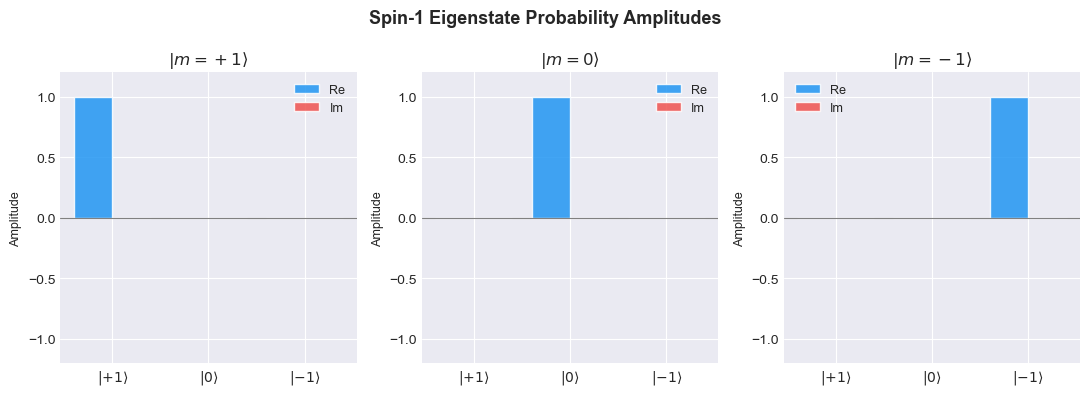

In [95]:
# Bar charts for spin-1 eigenstates
fig, axes = plt.subplots(1, 3, figsize=(11, 4))
fig.suptitle('Spin-1 Eigenstate Probability Amplitudes', fontsize=13, fontweight='bold')

states_j = [jm1,   j0,    jm_1  ]
titles_j = [r'$|m{=}+1\rangle$', r'$|m{=}0\rangle$', r'$|m{=}-1\rangle$']
basis_j  = [r'$|{+1}\rangle$', r'$|0\rangle$', r'$|{-1}\rangle$']
x = np.arange(3)

for ax, psi, title in zip(axes, states_j, titles_j):
    re = psi.real.flatten()
    im = psi.imag.flatten()
    ax.bar(x - 0.2, re, 0.4, label='Re', color='#2196F3', alpha=0.85, edgecolor='white')
    ax.bar(x + 0.2, im, 0.4, label='Im', color='#EF5350', alpha=0.85, edgecolor='white')
    ax.set_title(title, fontsize=12)
    ax.set_xticks(x); ax.set_xticklabels(basis_j, fontsize=10)
    ax.set_ylim(-1.2, 1.2)
    ax.axhline(0, color='gray', lw=0.8)
    ax.set_ylabel('Amplitude', fontsize=9)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

---
## 7. Photon Polarization

Photon polarization lives in a 2-dimensional complex Hilbert space —
formally **identical** to spin-½.

**Linear basis:**
$$
|x\rangle = \begin{pmatrix}1\\0\end{pmatrix}\!, \quad
|y\rangle = \begin{pmatrix}0\\1\end{pmatrix}
$$

**Circular basis** ($|R\rangle = \tfrac{1}{\sqrt{2}}(|x\rangle + i|y\rangle)$):
$$
|R\rangle = \frac{1}{\sqrt{2}}\begin{pmatrix}1\\i\end{pmatrix}\!, \quad
|L\rangle = \frac{1}{\sqrt{2}}\begin{pmatrix}1\\-i\end{pmatrix}
$$

Each basis is **complete** and **orthonormal**; the two are related by a
unitary transformation.

In [96]:
# Display polarization states — NumPy
print("── Polarization States (NumPy) ──\n")
pol_np   = [pol_x,  pol_y,  pol_R,  pol_L ]
pol_name = ['pol_x |x⟩', 'pol_y |y⟩', 'pol_R |R⟩', 'pol_L |L⟩']
for name, psi in zip(pol_name, pol_np):
    print(f"  {name}: {psi.T}")

── Polarization States (NumPy) ──

  pol_x |x⟩: [[1.+0.j 0.+0.j]]
  pol_y |y⟩: [[0.+0.j 1.+0.j]]
  pol_R |R⟩: [[0.70710678+0.j         0.        +0.70710678j]]
  pol_L |L⟩: [[0.70710678+0.j         0.        -0.70710678j]]


In [97]:
# Display polarization states — SymPy
print("── Polarization States (SymPy) ──\n")
pol_sym = [pol_x_sym, pol_y_sym, pol_R_sym, pol_L_sym]
pol_ltx = [r'|x\rangle', r'|y\rangle', r'|R\rangle', r'|L\rangle']
for lbl, psi in zip(pol_ltx, pol_sym):
    display(Math(lbl + r' = ' + sp.latex(psi)))

── Polarization States (SymPy) ──



<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [98]:
# Orthonormality within each basis
print("── Normalization ──\n")
for name, psi in zip([r'|x⟩', r'|y⟩', r'|R⟩', r'|L⟩'], pol_np):
    print(f"  norm({name}) = {norm(psi):.10f}")

print("\n── Orthogonality ──\n")
print(f"  ⟨x|y⟩ = {(dagger(pol_x) @ pol_y)[0,0]:.6f}  (linear basis)")
print(f"  ⟨R|L⟩ = {(dagger(pol_R) @ pol_L)[0,0]:.6f}  (circular basis)")

print("\n── Completeness ──\n")
comp_lin = pol_x @ dagger(pol_x) + pol_y @ dagger(pol_y)
comp_cir = pol_R @ dagger(pol_R) + pol_L @ dagger(pol_L)
print(f"  |x⟩⟨x| + |y⟩⟨y| = I₂ ?  {np.allclose(comp_lin, I2)}")
print(f"  |R⟩⟨R| + |L⟩⟨L| = I₂ ?  {np.allclose(comp_cir, I2)}")

── Normalization ──

  norm(|x⟩) = 1.0000000000
  norm(|y⟩) = 1.0000000000
  norm(|R⟩) = 1.0000000000
  norm(|L⟩) = 1.0000000000

── Orthogonality ──

  ⟨x|y⟩ = 0.000000+0.000000j  (linear basis)
  ⟨R|L⟩ = 0.000000+0.000000j  (circular basis)

── Completeness ──

  |x⟩⟨x| + |y⟩⟨y| = I₂ ?  True
  |R⟩⟨R| + |L⟩⟨L| = I₂ ?  True


In [99]:
# SymPy: completeness of circular basis
comp_cir_sym = (pol_R_sym * dagger(pol_R_sym)
                + pol_L_sym * dagger(pol_L_sym))
display(Math(r'|R\rangle\langle R| + |L\rangle\langle L| = '
             + sp.latex(sp.simplify(comp_cir_sym))))

<IPython.core.display.Math object>

In [100]:
# Change-of-basis: linear ↔ circular
print("── Change of Basis: Linear ↔ Circular ──\n")
r2 = np.sqrt(0.5)

print("Circular in terms of linear:")
print(f"  |R⟩ = (1/√2)(|x⟩ + i|y⟩) ?  {np.allclose(pol_R, r2*(pol_x + 1j*pol_y))}")
print(f"  |L⟩ = (1/√2)(|x⟩ - i|y⟩) ?  {np.allclose(pol_L, r2*(pol_x - 1j*pol_y))}")

print("\nLinear in terms of circular:")
print(f"  |x⟩ = (1/√2)(|R⟩ + |L⟩)   ?  {np.allclose(pol_x, r2*(pol_R + pol_L))}")
print(f"  |y⟩ = (i/√2)(|L⟩ - |R⟩)   ?  {np.allclose(pol_y, r2*1j*(pol_L - pol_R))}")

── Change of Basis: Linear ↔ Circular ──

Circular in terms of linear:
  |R⟩ = (1/√2)(|x⟩ + i|y⟩) ?  True
  |L⟩ = (1/√2)(|x⟩ - i|y⟩) ?  True

Linear in terms of circular:
  |x⟩ = (1/√2)(|R⟩ + |L⟩)   ?  True
  |y⟩ = (i/√2)(|L⟩ - |R⟩)   ?  True


In [101]:
# SymPy: change-of-basis identities (exact)
R2 = sp.Rational(1, 1) / sp.sqrt(2)
x_from_circ = sp.simplify(R2 * (pol_R_sym + pol_L_sym))
y_from_circ = sp.simplify(sp.I * R2 * (pol_L_sym - pol_R_sym))
display(Math(r'\frac{1}{\sqrt{2}}(|R\rangle + |L\rangle) = ' + sp.latex(x_from_circ)))
display(Math(r'\frac{i}{\sqrt{2}}(|L\rangle - |R\rangle) = ' + sp.latex(y_from_circ)))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

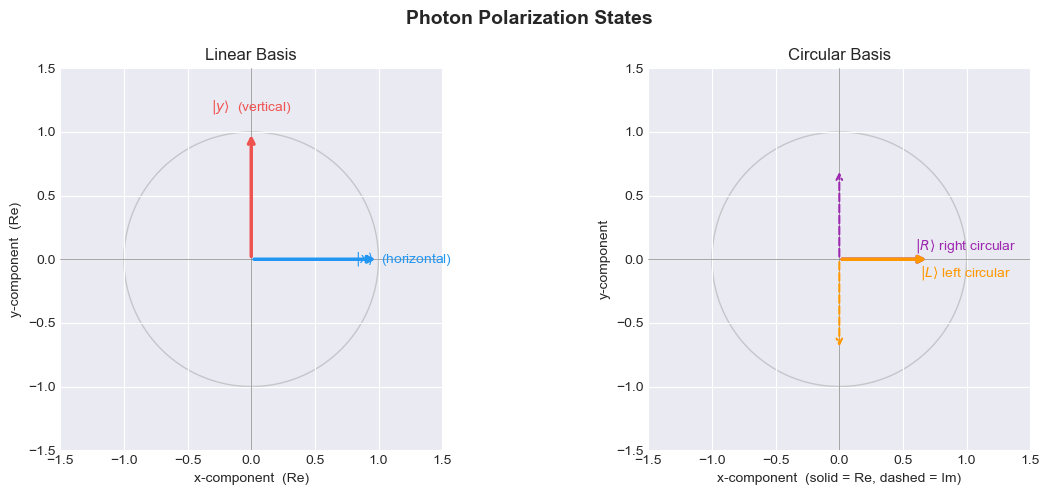

In [102]:
# Visualize polarization states as arrows on the unit circle
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Photon Polarization States', fontsize=14, fontweight='bold')
theta = np.linspace(0, 2*np.pi, 300)

# ── Left panel: linear basis ──────────────────────────────────────────────
ax = axes[0]
ax.plot(np.cos(theta), np.sin(theta), 'gray', lw=1, alpha=0.35, zorder=0)
ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
for psi, label, color in [
    (pol_x.flatten(), r'$|x\rangle$  (horizontal)', '#2196F3'),
    (pol_y.flatten(), r'$|y\rangle$  (vertical)',   '#EF5350'),
]:
    ex, ey = psi[0].real, psi[1].real
    ax.annotate('', xy=(ex, ey), xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color=color, lw=2.5))
    ax.text(ex * 1.2, ey * 1.2, label, color=color, fontsize=10,
            ha='center', va='center')
ax.set_xlim(-1.5, 1.5); ax.set_ylim(-1.5, 1.5); ax.set_aspect('equal')
ax.set_xlabel('x-component  (Re)', fontsize=10)
ax.set_ylabel('y-component  (Re)', fontsize=10)
ax.set_title('Linear Basis', fontsize=12)

# ── Right panel: circular basis ───────────────────────────────────────────
ax = axes[1]
ax.plot(np.cos(theta), np.sin(theta), 'gray', lw=1, alpha=0.35, zorder=0)
ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
for psi, label, color in [
    (pol_R.flatten(), r'$|R\rangle$ right circular', '#9C27B0'),
    (pol_L.flatten(), r'$|L\rangle$ left circular',  '#FF9800'),
]:
    re_x, re_y = psi[0].real, psi[1].real   # solid  = Re component
    im_x, im_y = psi[0].imag, psi[1].imag   # dashed = Im component
    ax.annotate('', xy=(re_x, re_y), xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color=color, lw=2.5))
    ax.annotate('', xy=(im_x, im_y), xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color=color, lw=1.5,
                                linestyle='dashed'))
    ax.text(re_x * 1.4 + im_x * 0.15, re_y * 1.35 + im_y * 0.15, label,
            color=color, fontsize=10, ha='center', va='center')
ax.set_xlim(-1.5, 1.5); ax.set_ylim(-1.5, 1.5); ax.set_aspect('equal')
ax.set_xlabel('x-component  (solid = Re, dashed = Im)', fontsize=10)
ax.set_ylabel('y-component', fontsize=10)
ax.set_title('Circular Basis', fontsize=12)

plt.tight_layout()
plt.show()

---
## 8. Helper Functions — Summary

All four utilities **auto-dispatch** to NumPy or SymPy depending on input type.

| Function | Formula | Returns |
|----------|---------|---------|
| `dagger(A)` | $A^\dagger$ | Conjugate transpose |
| `comm(A, B)` | $AB - BA$ | Commutator matrix |
| `expect(A, psi)` | $\langle\psi\lvert A\rvert\psi\rangle$ | Expectation value (scalar) |
| `norm(psi)` | $\sqrt{\langle\psi\lvert\psi\rangle}$ | State norm (real scalar) |

In [103]:
# ── dagger(A) ──────────────────────────────────────────────────────────────
print("── dagger(A) — Conjugate Transpose A† ──\n")

print("NumPy:")
print(f"  σ_y Hermitian (σ_y† = σ_y) ?  {np.allclose(dagger(sigma_y), sigma_y)}")
print(f"  dagger(spin_up) shape:  {dagger(spin_up).shape}   (column → row vector)")
print(f"  dagger(pol_R) = {dagger(pol_R)}")

print("\nSymPy:")
display(Math(r'\sigma_y^\dagger = ' + sp.latex(dagger(sigma_y_sym))))
display(Math(r'|R\rangle^\dagger = \langle R| = '
             + sp.latex(dagger(pol_R_sym))))

── dagger(A) — Conjugate Transpose A† ──

NumPy:
  σ_y Hermitian (σ_y† = σ_y) ?  True
  dagger(spin_up) shape:  (1, 2)   (column → row vector)
  dagger(pol_R) = [[0.70710678-0.j         0.        -0.70710678j]]

SymPy:


<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [104]:
# ── comm(A, B) ─────────────────────────────────────────────────────────────
print("── comm(A, B) — Commutator [A, B] ──\n")

print("NumPy (spin-½ Pauli algebra):")
print(f"  [σ_x, σ_y] = 2i·σ_z ?  {np.allclose(comm(sigma_x, sigma_y), 2j*sigma_z)}")
print(f"  [σ_y, σ_z] = 2i·σ_x ?  {np.allclose(comm(sigma_y, sigma_z), 2j*sigma_x)}")
print(f"  [σ_z, σ_x] = 2i·σ_y ?  {np.allclose(comm(sigma_z, sigma_x), 2j*sigma_y)}")

print("\nNumPy (spin-1 J algebra):")
print(f"  [J_x, J_y] = i·J_z ?  {np.allclose(comm(jx, jy), 1j*jz)}")
print(f"  [J_y, J_z] = i·J_x ?  {np.allclose(comm(jy, jz), 1j*jx)}")

print("\nSymPy (spin-½):")
display(Math(r'[\sigma_x, \sigma_y] = ' + sp.latex(comm(sigma_x_sym, sigma_y_sym))))

print("\nSymPy (spin-1):")
display(Math(r'[J_x, J_y] = ' + sp.latex(comm(jx_sym, jy_sym))))

── comm(A, B) — Commutator [A, B] ──

NumPy (spin-½ Pauli algebra):
  [σ_x, σ_y] = 2i·σ_z ?  True
  [σ_y, σ_z] = 2i·σ_x ?  True
  [σ_z, σ_x] = 2i·σ_y ?  True

NumPy (spin-1 J algebra):
  [J_x, J_y] = i·J_z ?  True
  [J_y, J_z] = i·J_x ?  True

SymPy (spin-½):


<IPython.core.display.Math object>


SymPy (spin-1):


<IPython.core.display.Math object>

In [105]:
# ── expect(A, psi) ─────────────────────────────────────────────────────────
print("── expect(A, psi) — Expectation Value ⟨ψ|A|ψ⟩ ──\n")

print("NumPy:")
rows = [
    (sigma_z, spin_up,   'σ_z', '|+⟩',     +1),
    (sigma_z, spin_down, 'σ_z', '|−⟩',     -1),
    (sigma_x, spin_up,   'σ_x', '|+⟩',      0),
    (sigma_x, xplus,     'σ_x', '|+x⟩',   +1),
    (jz,      jm1,       'J_z', '|m=+1⟩',  +1),
    (jz,      j0,        'J_z', '|m= 0⟩',   0),
    (jz,      jm_1,      'J_z', '|m=−1⟩',  -1),
]
for A, psi, Albl, plbl, expected in rows:
    val = expect(A, psi).real
    print(f"  ⟨{plbl[1:-1]}|{Albl}|{plbl[1:-1]}⟩ = {val:+.4f}   (expected {expected:+d})")

print("\nSymPy:")
display(Math(r'\langle+|\sigma_z|+\rangle = '
             + sp.latex(expect(sigma_z_sym, spin_up_sym))))
display(Math(r'\langle+x|\sigma_x|+x\rangle = '
             + sp.latex(expect(sigma_x_sym, xplus_sym))))
display(Math(r'\langle m{=}0|J_z|m{=}0\rangle = '
             + sp.latex(expect(jz_sym, j0_sym))))

── expect(A, psi) — Expectation Value ⟨ψ|A|ψ⟩ ──

NumPy:
  ⟨+|σ_z|+⟩ = +1.0000   (expected +1)
  ⟨−|σ_z|−⟩ = -1.0000   (expected -1)
  ⟨+|σ_x|+⟩ = +0.0000   (expected +0)
  ⟨+x|σ_x|+x⟩ = +1.0000   (expected +1)
  ⟨m=+1|J_z|m=+1⟩ = +1.0000   (expected +1)
  ⟨m= 0|J_z|m= 0⟩ = +0.0000   (expected +0)
  ⟨m=−1|J_z|m=−1⟩ = -1.0000   (expected -1)

SymPy:


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [106]:
# ── norm(psi) ──────────────────────────────────────────────────────────────
print("── norm(psi) — √⟨ψ|ψ⟩  (all should equal 1) ──\n")

all_states = [spin_up, spin_down, xplus, xminus, yplus, yminus,
              jm1, j0, jm_1, pol_x, pol_y, pol_R, pol_L]
all_names  = ['|+⟩', '|−⟩', '|+x⟩', '|−x⟩', '|+y⟩', '|−y⟩',
              '|m=+1⟩', '|m=0⟩', '|m=−1⟩', '|x⟩', '|y⟩', '|R⟩', '|L⟩']

print("NumPy:")
for name, psi in zip(all_names, all_states):
    n    = norm(psi)
    flag = '✓' if abs(n - 1.0) < 1e-12 else '✗'
    print(f"  {flag}  norm({name:<10}) = {n:.12f}")

print("\nSymPy (exact results):")
for lbl, psi in [(r'\lvert+x\rangle',      xplus_sym),
                 (r'\lvert R\rangle',       pol_R_sym),
                 (r'\lvert m{=}-1\rangle',  jm_1_sym)]:
    display(Math(r'\|' + lbl + r'\| = ' + sp.latex(norm(psi))))

── norm(psi) — √⟨ψ|ψ⟩  (all should equal 1) ──

NumPy:
  ✓  norm(|+⟩       ) = 1.000000000000
  ✓  norm(|−⟩       ) = 1.000000000000
  ✓  norm(|+x⟩      ) = 1.000000000000
  ✓  norm(|−x⟩      ) = 1.000000000000
  ✓  norm(|+y⟩      ) = 1.000000000000
  ✓  norm(|−y⟩      ) = 1.000000000000
  ✓  norm(|m=+1⟩    ) = 1.000000000000
  ✓  norm(|m=0⟩     ) = 1.000000000000
  ✓  norm(|m=−1⟩    ) = 1.000000000000
  ✓  norm(|x⟩       ) = 1.000000000000
  ✓  norm(|y⟩       ) = 1.000000000000
  ✓  norm(|R⟩       ) = 1.000000000000
  ✓  norm(|L⟩       ) = 1.000000000000

SymPy (exact results):


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

---
## 9. Mini Problems

Apply what you have learned. Answer cells are **hidden by default** — click
the ▶ icon to reveal each solution.

---
### Problem 1 — Expectation values in $|{+y}\rangle$

Using `expect()`, compute $\langle\sigma_x\rangle$, $\langle\sigma_y\rangle$,
$\langle\sigma_z\rangle$ for the state $|{+y}\rangle$.
Interpret the results physically.

*Hint:* $|{+y}\rangle$ is an eigenstate of $\sigma_y$ — what does that imply for $\langle\sigma_y\rangle$?

In [107]:
# ── ANSWER 1 ──
# |+y⟩ is the +1 eigenstate of σ_y  →  ⟨σ_y⟩ = +1 (certain).
# It is an equal-weight superposition of σ_x and σ_z eigenstates
# → ⟨σ_x⟩ = ⟨σ_z⟩ = 0.

print("── Answer to Problem 1 ──\n")
print("NumPy:")
for lbl, A in [('σ_x', sigma_x), ('σ_y', sigma_y), ('σ_z', sigma_z)]:
    val = expect(A, yplus).real
    print(f"  ⟨{lbl}⟩ in |+y⟩ = {val:+.6f}")

print("\nSymPy (exact):")
for lbl, A in [(r'\sigma_x', sigma_x_sym),
               (r'\sigma_y', sigma_y_sym),
               (r'\sigma_z', sigma_z_sym)]:
    val = expect(A, yplus_sym)
    display(Math(r'\langle+y|\,' + lbl + r'\,|+y\rangle = ' + sp.latex(val)))

print("\nInterpretation:")
print("  |+y⟩ is a σ_y eigenstate → ⟨σ_y⟩ = +1 (measuring σ_y always gives +1).")
print("  ⟨σ_x⟩ = ⟨σ_z⟩ = 0: equal probability of ±1, consistent with the")
print("  uncertainty principle for non-commuting observables.")

── Answer to Problem 1 ──

NumPy:
  ⟨σ_x⟩ in |+y⟩ = +0.000000
  ⟨σ_y⟩ in |+y⟩ = +1.000000
  ⟨σ_z⟩ in |+y⟩ = +0.000000

SymPy (exact):


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>


Interpretation:
  |+y⟩ is a σ_y eigenstate → ⟨σ_y⟩ = +1 (measuring σ_y always gives +1).
  ⟨σ_x⟩ = ⟨σ_z⟩ = 0: equal probability of ±1, consistent with the
  uncertainty principle for non-commuting observables.


---
### Problem 2 — Heisenberg Uncertainty Relation for spin-½

For the state $|{+}\rangle$, verify the uncertainty relation:

$$
\Delta\sigma_x \cdot \Delta\sigma_y \;\geq\; \tfrac{1}{2}\,
|\langle[\sigma_x,\,\sigma_y]\rangle|
= |\langle\sigma_z\rangle|
$$

where $(\Delta\sigma_i)^2 = \langle\sigma_i^2\rangle - \langle\sigma_i\rangle^2$.

*Hint:* $[\sigma_x,\sigma_y] = 2i\sigma_z$, so
$\tfrac{1}{2}|\langle[\sigma_x,\sigma_y]\rangle| = |\langle\sigma_z\rangle|$.

In [108]:
# ── ANSWER 2 ──
print("── Answer to Problem 2 ──\n")
psi = spin_up

ex_x  = expect(sigma_x, psi).real
ex_y  = expect(sigma_y, psi).real
ex_z  = expect(sigma_z, psi).real
ex_x2 = expect(sigma_x @ sigma_x, psi).real    # σ_x² = I → always 1
ex_y2 = expect(sigma_y @ sigma_y, psi).real    # σ_y² = I → always 1

Dx  = np.sqrt(ex_x2 - ex_x**2)
Dy  = np.sqrt(ex_y2 - ex_y**2)
rhs = abs(ex_z)

print(f"  ⟨σ_x⟩  = {ex_x:+.6f}")
print(f"  ⟨σ_y⟩  = {ex_y:+.6f}")
print(f"  ⟨σ_z⟩  = {ex_z:+.6f}")
print(f"  Δσ_x   = {Dx:.6f}")
print(f"  Δσ_y   = {Dy:.6f}")
print(f"  Δσ_x · Δσ_y = {Dx*Dy:.6f}")
print(f"  RHS = |⟨σ_z⟩| = {rhs:.6f}")
print(f"\n  Uncertainty relation satisfied?  {Dx*Dy >= rhs - 1e-10}  ({Dx*Dy:.4f} ≥ {rhs:.4f})")
print("\nNote: |+⟩ is a σ_z eigenstate (no uncertainty in z) but has")
print("maximum uncertainty in σ_x and σ_y — the relation is saturated.")

── Answer to Problem 2 ──

  ⟨σ_x⟩  = +0.000000
  ⟨σ_y⟩  = +0.000000
  ⟨σ_z⟩  = +1.000000
  Δσ_x   = 1.000000
  Δσ_y   = 1.000000
  Δσ_x · Δσ_y = 1.000000
  RHS = |⟨σ_z⟩| = 1.000000

  Uncertainty relation satisfied?  True  (1.0000 ≥ 1.0000)

Note: |+⟩ is a σ_z eigenstate (no uncertainty in z) but has
maximum uncertainty in σ_x and σ_y — the relation is saturated.


---
### Problem 3 — Superposition state in spin-1

Construct the (unnormalized) state
$|\psi\rangle = |m{=}+1\rangle + |m{=}-1\rangle$,
normalize it with `norm()`, then compute $\langle J_z\rangle$ and $\langle J_x\rangle$.
Interpret the results.

In [109]:
# ── ANSWER 3 ──
print("── Answer to Problem 3 ──\n")
psi_raw  = jm1 + jm_1
n        = norm(psi_raw)
psi      = psi_raw / n

print(f"  norm of |m=+1⟩ + |m=−1⟩ = {n:.6f}  (= √2, as expected)")
print(f"  Normalized psi = {psi.T}")

jz_exp = expect(jz, psi).real
jx_exp = expect(jx, psi).real
jy_exp = expect(jy, psi).real

print(f"\n  ⟨J_z⟩ = {jz_exp:+.6f}   (expected 0: symmetric superposition)")
print(f"  ⟨J_x⟩ = {jx_exp:+.6f}")
print(f"  ⟨J_y⟩ = {jy_exp:+.6f}")

# SymPy exact
R2    = sp.Rational(1, 1) / sp.sqrt(2)
p_sym = R2 * (jm1_sym + jm_1_sym)
print("\nSymPy exact:")
display(Math(r'\langle\psi|J_z|\psi\rangle = '
             + sp.latex(sp.simplify(expect(jz_sym, p_sym)))))
display(Math(r'\langle\psi|J_x|\psi\rangle = '
             + sp.latex(sp.simplify(expect(jx_sym, p_sym)))))

print("\nInterpretation:")
print("  Equal +1 and −1 components → ⟨J_z⟩ = 0.")
print("  Non-zero ⟨J_x⟩ shows transverse spin polarization.")

── Answer to Problem 3 ──

  norm of |m=+1⟩ + |m=−1⟩ = 1.414214  (= √2, as expected)
  Normalized psi = [[0.70710678+0.j 0.        +0.j 0.70710678+0.j]]

  ⟨J_z⟩ = +0.000000   (expected 0: symmetric superposition)
  ⟨J_x⟩ = +0.000000
  ⟨J_y⟩ = +0.000000

SymPy exact:


<IPython.core.display.Math object>

<IPython.core.display.Math object>


Interpretation:
  Equal +1 and −1 components → ⟨J_z⟩ = 0.
  Non-zero ⟨J_x⟩ shows transverse spin polarization.


---
### Problem 4 — Photon polarization probability

A photon is prepared in the right-circular state $|R\rangle$.

(a) What is the probability of measuring horizontal polarization $|x\rangle$?
Vertical polarization $|y\rangle$?

(b) Verify with SymPy that both probabilities equal exactly $\tfrac{1}{2}$.

In [110]:
# ── ANSWER 4 ──
print("── Answer to Problem 4 ──\n")

# (a) P(|x⟩) = |⟨x|R⟩|²
amp_x = (dagger(pol_x) @ pol_R)[0, 0]
amp_y = (dagger(pol_y) @ pol_R)[0, 0]
P_x   = abs(amp_x)**2
P_y   = abs(amp_y)**2

print("(a) NumPy:")
print(f"  ⟨x|R⟩ = {amp_x:.6f}   →   P(|x⟩) = {P_x:.6f}")
print(f"  ⟨y|R⟩ = {amp_y:.6f}   →   P(|y⟩) = {P_y:.6f}")
print(f"  P(x) + P(y) = {P_x + P_y:.6f}  ✓")

# (b) SymPy
print("\n(b) SymPy (exact):")
ax_sym = (dagger(pol_x_sym) * pol_R_sym)[0, 0]
ay_sym = (dagger(pol_y_sym) * pol_R_sym)[0, 0]
display(Math(r'\langle x|R\rangle = ' + sp.latex(ax_sym)))
display(Math(r'\langle y|R\rangle = ' + sp.latex(ay_sym)))
display(Math(r'P(|x\rangle) = |\langle x|R\rangle|^2 = '
             + sp.latex(sp.Abs(ax_sym)**2)))
display(Math(r'P(|y\rangle) = |\langle y|R\rangle|^2 = '
             + sp.latex(sp.Abs(ay_sym)**2)))

print("\nInterpretation:")
print("  |R⟩ is an equal superposition of |x⟩ and |y⟩ (they differ only")
print("  in the relative phase i), so each linear polarization is detected")
print("  with probability exactly 1/2.")

── Answer to Problem 4 ──

(a) NumPy:
  ⟨x|R⟩ = 0.707107+0.000000j   →   P(|x⟩) = 0.500000
  ⟨y|R⟩ = 0.000000+0.707107j   →   P(|y⟩) = 0.500000
  P(x) + P(y) = 1.000000  ✓

(b) SymPy (exact):


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>


Interpretation:
  |R⟩ is an equal superposition of |x⟩ and |y⟩ (they differ only
  in the relative phase i), so each linear polarization is detected
  with probability exactly 1/2.


---
### Problem 5 — Ladder-operator commutator algebra

Use `comm()` to verify all three relations defining the su(2) algebra in the
ladder-operator basis, for both NumPy and SymPy:

$$
[\sigma_+,\,\sigma_-] = \sigma_z, \qquad
[\sigma_z,\,\sigma_+] = 2\sigma_+, \qquad
[\sigma_z,\,\sigma_-] = -2\sigma_-
$$

In [111]:
# ── ANSWER 5 ──
print("── Answer to Problem 5 ──\n")

print("NumPy:")
print(f"  [σ₊, σ₋] = σ_z   ?  "
      f"{np.allclose(comm(sigma_plus,  sigma_minus), sigma_z)}")
print(f"  [σ_z, σ₊] = 2σ₊  ?  "
      f"{np.allclose(comm(sigma_z, sigma_plus), 2*sigma_plus)}")
print(f"  [σ_z, σ₋] = -2σ₋ ?  "
      f"{np.allclose(comm(sigma_z, sigma_minus), -2*sigma_minus)}")

print("\nSymPy (exact):")
for expr, lhs_label in [
    (comm(sigma_plus_sym,  sigma_minus_sym), r'[\sigma_+,\,\sigma_-]'),
    (comm(sigma_z_sym,     sigma_plus_sym),  r'[\sigma_z,\,\sigma_+]'),
    (comm(sigma_z_sym,     sigma_minus_sym), r'[\sigma_z,\,\sigma_-]'),
]:
    display(Math(lhs_label + r' = ' + sp.latex(expr)))

print("\nNote: these relations define the su(2) algebra in the")
print("raising/lowering basis — the building blocks of angular-momentum")
print("theory used throughout atomic, nuclear, and particle physics.")

── Answer to Problem 5 ──

NumPy:
  [σ₊, σ₋] = σ_z   ?  True
  [σ_z, σ₊] = 2σ₊  ?  True
  [σ_z, σ₋] = -2σ₋ ?  True

SymPy (exact):


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>


Note: these relations define the su(2) algebra in the
raising/lowering basis — the building blocks of angular-momentum
theory used throughout atomic, nuclear, and particle physics.


In [112]:
amp = (dagger(yplus) @ spin_up)
print(f"\n⟨+y|+⟩ = {amp[0,0]:.6f}  →  P(|+y⟩) = {abs(amp[0,0])**2:.6f}")



⟨+y|+⟩ = 0.707107+0.000000j  →  P(|+y⟩) = 0.500000


In [113]:
amp = (dagger(yminus) @ spin_up)[0, 0]
print("<-y|+z> =", amp)
print("|<-y|+z>|^2 =", abs(amp)**2)

<-y|+z> = (0.7071067811865476+0j)
|<-y|+z>|^2 = 0.5000000000000001


In [114]:
sigma_x_sym*sigma_x_sym


Matrix([
[1, 0],
[0, 1]])

In [115]:
sigma_y_sym*sigma_y_sym

Matrix([
[1, 0],
[0, 1]])

In [116]:
sigma_z_sym*sigma_z_sym

Matrix([
[1, 0],
[0, 1]])

In [117]:
comm( sigma_x_sym, sigma_y_sym)

Matrix([
[2*I,    0],
[  0, -2*I]])

In [119]:
sigma_z_sym * spin_down_sym


Matrix([
[ 0],
[-1]])